#  Logo Retrieval System

## Import Libraries

In [1]:
!pip install datasets --no-warn-conflicts --quiet
!pip install faiss-cpu --no-warn-conflicts --quiet

import os
import json
import datasets
import faiss
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import torch
from PIL import Image
import torchvision
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 45.8 MB/s eta 0:00:00


## Configuration

In [2]:
import os
from pathlib import Path
import torch


class Config:
    """
    Configuration class for the project.
    """
    # ========== Base Paths ==========
    project_name = "logo_recognition_similarity_search_project"
    base_dir = Path("/content/drive/MyDrive")/project_name
    output_dir = base_dir / "output"
    cache_dir = base_dir / "cache"

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    # ========== Dataset ==========
    dataset_path = "mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset"
    dataset_cache_dir = cache_dir / dataset_path.split("/")[-1]
    batch_size = 1024  #512,2048,1024

    # ========== Runtime ==========
    device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
    num_workers = 4 if os.cpu_count()>=4 else 0
    seed = 42

    # ========== Model ==========
    model_path = 'mlproject5606/Logo-Recognition-ResNet50-TripletNet-Retrieval'
    output_model_dir = output_dir / model_path.split("/")[-1]
    input_dim = 2048
    embed_dim = 256

    # ========== Retrieval ==========
    top_k = 5
    faiss_index_column = "tripletnet_embedding"
    dataset_with_embeddings_path = "mlproject5606/Logo-Recognition-ResNet50-TripletNet-Embeddings-Dataset"
    dataset_with_embeddings_cache_dir = cache_dir / dataset_with_embeddings_path.split("/")[-1]







# Create Configuration Object
cfg = Config()

## Load Dataset

In [ ]:
# from datasets import load_dataset

ds = load_dataset(
    path = cfg.dataset_path,
    cache_dir = cfg.dataset_cache_dir,
    )
# ds

In [ ]:
from datasets import load_from_disk

ds = load_from_disk(cfg.dataset_cache_dir)
ds

In [ ]:
# Inspect the structure of the dataset
ds['test'].features

## Retrieval

### Triplet Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision.transforms import Compose
from typing import List, Union, Optional, Dict
from PIL import Image
from huggingface_hub import hf_hub_download
import joblib

class GenericBackbone(nn.Module):
    def __init__(
        self,
        model: nn.Module,
        weights_meta: dict,
        transform: Compose,
        freeze: bool = True,
        return_layers: Optional[List[str]] = None,
        remove_layers: Optional[List[str]] = None,
        device: Optional[torch.device] = None,
    ):
        """
        Generic backbone wrapper for torchvision vision models.

        Args:
            model: Torchvision model (e.g., resnet50).
            weights_meta: Metadata from the weights object.
            transform: Recommended transform for input preprocessing.
            freeze: Whether to freeze model weights (default: True).
            return_layers: List of intermediate layers to capture via hooks.
            remove_layers: List of layer names to remove from model (e.g. ["fc"]).
            device: Device to use.
        """
        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.transform = transform
        self.weights_meta = weights_meta
        self.return_layers = return_layers or []
        self.remove_layers = remove_layers or []


        # Apply remove_layers dynamically
        for layer_name in self.remove_layers:
            if hasattr(model, layer_name):
                setattr(model, layer_name, nn.Identity())

        self.model = model.to(self.device).eval()

        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False

        # Prepare storage for hook outputs
        self._outputs: Dict[str, torch.Tensor] = {}
        self._register_hooks()

    def _register_hooks(self):
        """
        Register forward hooks for layers specified in return_layers.
        """
        for name, module in self.model.named_modules():
            if name in self.return_layers:
                module.register_forward_hook(self._get_hook(name))

    def _get_hook(self, name: str):
        def hook(module, input, output):
            self._outputs[name] = output.detach().cpu()
        return hook

    def _prepare_input(self, images: Union[Image.Image, List[Image.Image]]) -> torch.Tensor:
        """
        Transform PIL image(s) and prepare a batch tensor.
        """
        if isinstance(images, Image.Image):
            images = [images]
        return torch.stack([self.transform(img) for img in images]).to(self.device)


    def _get_last_valid_layer_name(self) -> Optional[str]:
        """
        Return the name of the last non-Identity layer in the model.
        """
        for name, module in reversed(list(self.model.named_modules())):
            if not isinstance(module, nn.Identity):
                return name
        return None


    def forward(self,images: Union[Image.Image, List[Image.Image]]) -> Dict[str, torch.Tensor]:
        """
        Forward pass through the model.

        Returns:
            - If return_layers are set: returns a dict of requested layer outputs.
            - If return_layers is empty: returns dict with model output under key <final_layer_name>.
        """
        self._outputs = {}

        try:
            x = self._prepare_input(images)

            with torch.no_grad():
                output = self.model(x).cpu()

            if not self.return_layers:
                # last_layer_name = self._get_last_valid_layer_name()
                return output

            return self._outputs

        except Exception as e:
            print(f"[Forward Error] {e}")
            raise e


    def predict_topk(self,logits: torch.Tensor,topk: int = 5) -> Union[List[tuple], List[List[tuple]]]:
        """
        Given model logits, return top-k class predictions and probabilities.

        Args:
            logits: Output from model (shape: [B, num_classes] or [num_classes]).
            topk: Number of top classes to return.

        Returns:
            List of {"label": ..., "score": ...} for each image.
        """
        single = logits.dim() == 1
        if single:
            logits = logits.unsqueeze(0)

        probs = F.softmax(logits, dim=1)
        values, indices = torch.topk(probs, k=topk, dim=1)

        labels = self.weights_meta["categories"]

        results = [
            [{"label": labels[idx], "score": round(values[i].item(), 5)} for i, idx in enumerate(idxs)]
            for values, idxs in zip(values, indices)
        ]

        return results[0] if single else results

# .......................................................................

class TripletEmbeddingNet(nn.Module):
    """
    A simple projection head that maps high-dimensional embeddings (e.g., 2048-d)
    into a lower-dimensional space (e.g., 256-d) to improve training stability.
    """

    def __init__(self,
                 backbone: Optional[nn.Module] = None,
                 input_dim: int=2048,
                 embed_dim: int=256
                 ):
        super().__init__()
        self.backbone = backbone
        self.projector = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, embed_dim)
        )

    def forward(self, x):
        if self.backbone is not None:
            x = self.backbone(x)
        x = x.view(x.size(0), -1)  # Flatten the input
        return F.normalize(self.projector(x), p=2, dim=1)  # L2-normalization

# .......................................................................
class TripletLoss(nn.Module):
    """
    Triplet Margin Loss with optional margin and L2 norm.
    """

    def __init__(self, margin=1.0,p=2,reduction='mean'):
        super().__init__()
        self.loss_fn = nn.TripletMarginLoss(margin=margin, p=p, reduction=reduction)

    def forward(self, anchor, positive, negative):
        return self.loss_fn(anchor, positive, negative)

# .......................................................................

class TripletNet(nn.Module):
    """
    Wraps the embedding model and computes outputs for anchor, positive, and negative.
    """

    def __init__(self, embedding_net: nn.Module):
        super().__init__()
        self.embedding_net = embedding_net

    def forward(self, anchor, positive = None, negative = None):
        embeds = []
        for x in [anchor, positive, negative]:
            if x is not None:
                embeds.append(self.embedding_net(x))
        return embeds

    def forward_projector(self,anchor, positive = None, negative = None):
        embeds = []
        for x in [anchor, positive, negative]:
            if x is not None:
                x = x.view(x.size(0), -1)  # Flatten the input
                embeds.append(F.normalize(self.embedding_net.projector(x), p=2, dim=1))
        return embeds

# .......................................................................

# Load a pretrained ResNet50 model with ImageNet V2 weights

weights = models.ResNet50_Weights.IMAGENET1K_V2
resnet50 = models.resnet50(weights=weights)

backbone = GenericBackbone(
    model=resnet50,
    weights_meta=weights.meta,
    transform=weights.transforms(),
    freeze=True,
    remove_layers=["fc"],
    return_layers=[],
    device=cfg.device
)


embedding_net = TripletEmbeddingNet(
                                     backbone = backbone,
                                     input_dim = cfg.input_dim,
                                     embed_dim = cfg.embed_dim
                                    )

model = TripletNet(embedding_net)



REPO_ID = cfg.model_path

model.load_state_dict(
    torch.load(
        hf_hub_download(repo_id=REPO_ID, filename="model.pt"),
        map_location=cfg.device
    )
)
model.embedding_net.backbone = backbone
model.to(cfg.device)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 320MB/s]


model.pt:   0%|          | 0.00/99.1M [00:00<?, ?B/s]

TripletNet(
  (embedding_net): TripletEmbeddingNet(
    (backbone): GenericBackbone(
      (transform): ImageClassification(
          crop_size=[224]
          resize_size=[232]
          mean=[0.485, 0.456, 0.406]
          std=[0.229, 0.224, 0.225]
          interpolation=InterpolationMode.BILINEAR
      )
      (model): ResNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          

### Computing Embeddings

In [ ]:
import torch

def extract_embeddings(model: torch.nn.Module):
    """Utility to compute embeddings."""
    def get_embeddings(batch):
        resnet50_embedding = torch.stack([torch.tensor(x) for x in batch['resnet50_embedding']]).to(cfg.device)
        resnet50_embedding = resnet50_embedding.view(resnet50_embedding.shape[0], -1)
        with torch.no_grad():
            embeddings = model.forward_projector(resnet50_embedding)[0].cpu()
        return {"resnet50_embedding":resnet50_embedding,"tripletnet_embedding": embeddings}
    return get_embeddings

In [ ]:
extract_fn = extract_embeddings(model)

test_ds = ds['test']

test_ds = test_ds.map(extract_fn,
                      batched=True,
                      batch_size=cfg.batch_size,
                      desc="Extracting embeddings for test set",
                      )

test_ds = test_ds.select_columns(['id',
                                  'path',
                                  'path_category',
                                  'prompt',
                                  'image',
                                  'resnet50_embedding',
                                  'tripletnet_embedding',
                                  'category',
                                  'resnet50_class'
                                  ])

test_ds.push_to_hub(
    f"logo-recognition-test-resnet50-tripletnet-embeddings",
    split="test",
    private=True,
    )

# .......................................................................
extract_fn = extract_embeddings(model)

train_ds = ds['train']

train_ds = train_ds.map(extract_fn,
                        batched=True,
                        batch_size=cfg.batch_size,
                        desc="Extracting embeddings for train set",
                        )

train_ds = train_ds.select_columns(['id',
                                    'path',
                                    'path_category',
                                    'prompt',
                                    'image',
                                    'resnet50_embedding',
                                    'tripletnet_embedding',
                                    'category',
                                    'resnet50_class'
                                    ])

train_ds.push_to_hub(
    f"logo-recognition-train-resnet50-tripletnet-embeddings",
    split="train",
    private=True,
    )


# .......................................................................
ds_with_embeddings = datasets.DatasetDict({
    'train': train_ds,
    'test': test_ds
})

ds_with_embeddings.push_to_hub(
    cfg.dataset_with_embeddings_path,
    private=True,
    )

### FAISS


In [ ]:
from datasets import load_dataset

ds_with_embeddings = load_dataset(
    path = cfg.dataset_with_embeddings_path,
    cache_dir = cfg.dataset_with_embeddings_cache_dir,
    )
ds_with_embeddings

README.md:   0%|          | 0.00/821 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/90 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/90 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

...

train-00079-of-00090.parquet:   0%|          | 0.00/495M [00:00<?, ?B/s]

train-00080-of-00090.parquet:   0%|          | 0.00/496M [00:00<?, ?B/s]

train-00081-of-00090.parquet:   0%|          | 0.00/496M [00:00<?, ?B/s]

train-00082-of-00090.parquet:   0%|          | 0.00/494M [00:00<?, ?B/s]

train-00083-of-00090.parquet:   0%|          | 0.00/493M [00:00<?, ?B/s]

In [ ]:
ds_with_embeddings.save_to_disk(cfg.dataset_with_embeddings_cache_dir)

In [ ]:
from datasets import load_from_disk

ds_with_embeddings = load_from_disk(cfg.dataset_with_embeddings_cache_dir)
ds_train_with_embeddings = ds_with_embeddings['train']

FileNotFoundError: Directory /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Logo-Recognition-ResNet50-TripletNet-Embeddings-Dataset not found

In [ ]:
def faiss_search(ds: datasets.Dataset,column: str,k: int = 5):
    ds = ds.add_faiss_index(column=column)

    def search(embedding_query):
        if not isinstance(embedding_query, np.ndarray):
            embedding_query = np.array(embedding_query)
        scores, examples = ds.get_nearest_examples(column,embedding_query,k=k)
        examples['resnet50_class'] = list(map(lambda item: [labels["label"] for labels in item],
                                               examples['resnet50_class']))
        return scores, examples
    return search

In [ ]:
search_fn = faiss_search(
    ds = ds_train_with_embeddings,
    column = cfg.faiss_index_column,
    k = cfg.top_k
    )

  0%|          | 0/1459 [00:00<?, ?it/s]

### Utilities

In [ ]:
import matplotlib.pyplot as plt

def plot_images(
        images,
        labels,
        categorys,
        image_query = None,
        caption_query = None,
        ):

    plt.figure(figsize=(20, 15))
    columns = 3
    ii= 0

    if image_query is not None:
        ax = plt.subplot(len(images) // columns + 1, columns,1)
        if caption_query is not None:
            ax.set_title("Query Image\n" + caption_query)
        else:
            ax.set_title("Query Image")
        plt.imshow(np.array(image_query).astype("int"))
        plt.axis("off")
        ii += 1


    for (i, image) in enumerate(images):
        ax = plt.subplot(len(images) // columns + 1, columns, i + 1+ii)
        ax.set_title(
            "Similar Image # " + str(i+1) + "\nCategory: {}".format(categorys[i]) + "\nLabels: \n{}".format('\n'.join(labels[i]))
        )
        plt.imshow(np.array(image).astype("int"))
        plt.axis("off")

In [ ]:
from PIL import Image
import requests
from io import BytesIO
from typing import Union, List,Any

def load_image(input: Union[Any, List[Any]]) -> Union[Image.Image, List[Image.Image]]:
    """

    """
    def load_single(input_data) -> Image.Image:
        if isinstance(input_data, Image.Image):
            return input_data
        if isinstance(input_data, str):
            if input_data.startswith("http"):
                response = requests.get(input_data)
                return Image.open(BytesIO(response.content)).convert("RGB")
            else:
                return Image.open(input_data).convert("RGB")
        raise ValueError("Input must be a PIL.Image or a valid image URL.")


    if isinstance(input, list):
        return [load_single(x) for x in input]
    return load_single(input)


In [ ]:
def compute_query_embedding(images:Union[Image.Image,List[Image.Image]],
                            model: torch.nn.Module) -> torch.Tensor:
    """
    Compute tripletnet embedding for a given images.
    """
    with torch.no_grad():
        embedding = model(images)[0].numpy()
    return embedding

## Evaluation

In [ ]:
def evaluate_recall(test_ds, search_fn):
    """
    Evaluate Recall@K on test dataset using both category and resnet50_class.
    """

    def compute_recall(sample):
        embedding = sample["tripletnet_embedding"]
        _,retrieved = search_fn(embedding)

        true_category = sample["category"]
        retrieved_categories = retrieved["category"]

        true_top_labels = set(x["label"] for x in sample["resnet50_class"])
        retrieved_labels = set([label for sublist in retrieved["resnet50_class"] for label in sublist])


        if true_category in retrieved_categories:
            correct_category = 1
        else:
            correct_category = 0

        if true_top_labels & retrieved_labels:
            correct_resnet50 = 1
        else:
            correct_resnet50 = 0

        sample["correct_category"] = correct_category
        sample["correct_resnet50"] = correct_resnet50

        return sample


    test_ds = test_ds.map(compute_recall,
                          num_proc=4,
                          desc="Evaluating Recall@K"
                          )
    test_ds.save_to_disk(cfg.cache_dir / "test_ds_with_recall")

    correct_category = sum(test_ds["correct_category"])
    correct_resnet50 = sum(test_ds["correct_resnet50"])

    evaluation_results  = {
        "recall_category":  correct_category / len(test_ds),
        "recall_resnet50":  correct_resnet50 / len(test_ds)
    }
    return evaluation_results


In [ ]:
ds_test_with_embeddings = ds_with_embeddings['test']
ds_test_with_embeddings

Dataset({
    features: ['id', 'path', 'path_category', 'prompt', 'image', 'resnet50_embedding', 'tripletnet_embedding', 'category', 'resnet50_class'],
    num_rows: 319471
})

In [ ]:
evaluation_results = evaluate_recall(test_ds = ds_test_with_embeddings,search_fn = search_fn)

evaluation_results

In [ ]:
with open(cfg.output_model_dir / "evaluation_results.json", "w") as f:
    json.dump(evaluation_results, f)

In [ ]:
with open(cfg.output_model_dir / "evaluation_results.json", "r") as f:
    evaluation_results = json.load(f)

evaluation_results

{'recall_category': 0.5314598195141343, 'recall_resnet50': 0.9639685605266206}

## Inference

In [ ]:
ds_test_with_embeddings = ds_with_embeddings['test']
ds_test_with_embeddings

Dataset({
    features: ['id', 'path', 'path_category', 'prompt', 'image', 'resnet50_embedding', 'tripletnet_embedding', 'category', 'resnet50_class'],
    num_rows: 319471
})

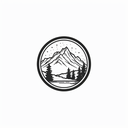

In [ ]:
index = 500
image_query = ds_test_with_embeddings[index]['image']
category_query = ds_test_with_embeddings[index]['category']
resnet50_class_query = [x['label'] for x in ds_test_with_embeddings[index]['resnet50_class']]
caption_query = f"Category: {category_query}\n Labels: \n{chr(10).join(resnet50_class_query)}"

image_query

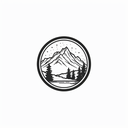

In [ ]:
image_query = load_image(image_query)
image_query

In [ ]:
embedding_query = compute_query_embedding(image_query,model)
embedding_query.shape

In [ ]:
 scores, examples = search_fn(embedding_query)

plot_images(
    images=examples['image'],
    labels=examples['resnet50_class'],
    categorys=examples['category'],
    image_query=image_query,
    caption_query=caption_query,
    )

## Disconnect & Delete Colab Runtime

In [ ]:
# Disconnect and delete the current runtime in Google Colab
from google.colab import runtime

runtime.unassign()